In [1]:
#Introduccion a tensorflow

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt

print(f"Versión de TensorFlow: {tf.__version__}")

Versión de TensorFlow: 2.20.0


In [2]:
print(tf.keras.__version__)
print("a")

3.13.2
a


In [3]:
print("GPU disponible: ", tf.config.list_physical_devices('GPU'))

GPU disponible:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
Fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = Fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']



In [8]:
train_images.shape

(60000, 28, 28)

In [7]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

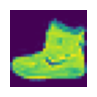

In [11]:
plt.figure(figsize=(1,1))
plt.imshow(train_images[0])
plt.axis('off')
plt.show()

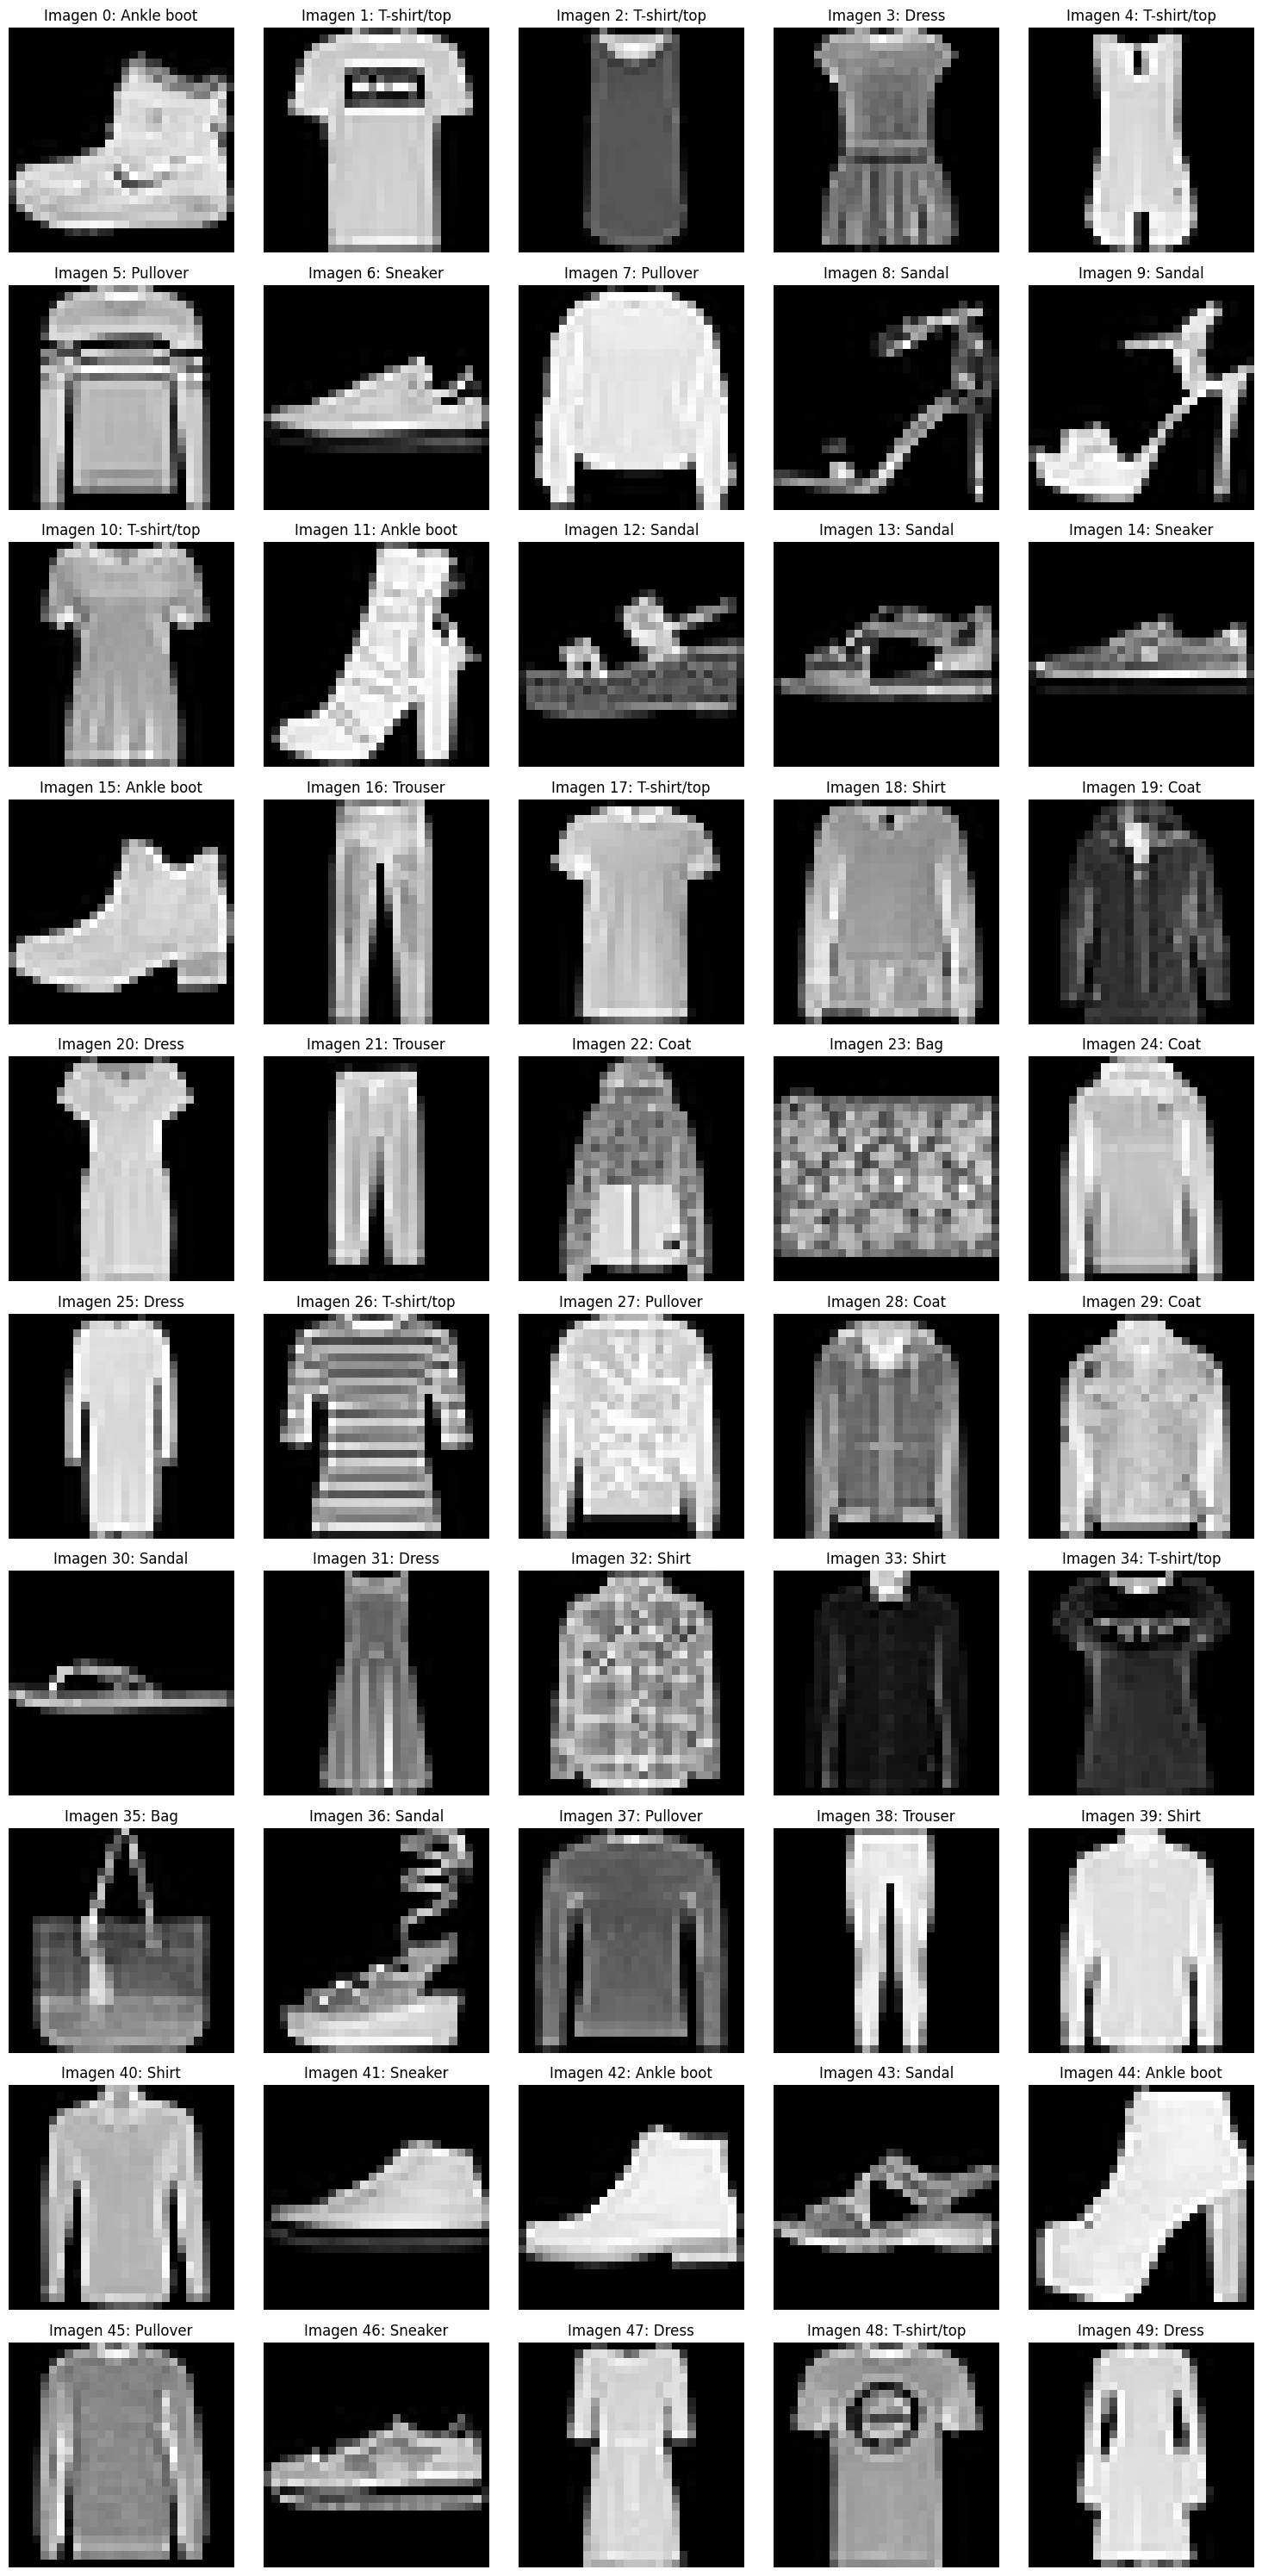

In [15]:
n_imagenes = min(50, len(train_images))
fig, axes = plt.subplots(10, 5, figsize=(15, 30))

for numero, ax in enumerate(axes.flat):
    if numero < n_imagenes:
        ax.imshow(train_images[numero], cmap='gray')
        nombre_clase = class_names[train_labels[numero]]
        ax.set_title(f'Imagen {numero}: {nombre_clase}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [22]:
# 1. Definir la entrada explícita
entradas = layers.Input(shape=(28, 28), name="Entrada")

# 2. Conectar cada capa pasándole la variable anterior entre paréntesis
capa_1 = layers.Flatten(name="Aplanado")(entradas)
capa_2 = layers.Dense(64, activation='relu', name="Oculta_1")(capa_1)
capa_3 = layers.Dropout(0.2, name="Dropout")(capa_2)
capa_4 = layers.Dense(32, activation='relu', name="Oculta_2")(capa_3)
capa_5 = layers.Dense(16, activation='relu', name="Oculta_3")(capa_4)
salida = layers.Dense(10, activation='softmax', name="Salida")(capa_5)

# 3. Encapsular definiendo explícitamente la entrada y la salida del modelo
model = models.Model(inputs=entradas, outputs=salida, name="Modelo_Funcional")

In [30]:
model.compile(optimizer=optimizers.Adam(),
              loss=losses.SparseCategoricalCrossentropy(),
              metrics=[metrics.SparseCategoricalAccuracy(name='accuracy')])

In [31]:
model.save('Fashion_mnist_model.keras')

In [33]:
predictions = model.predict(test_images)
posicion = np.argmax(predictions[0])
print(f'Clase predicha: {class_names[posicion]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Clase predicha: T-shirt/top


In [34]:
from google.colab import drive

drive.mount('/content/drive')

ruta_modelo = '/content/drive/MyDrive/CLase_ciencia_datos_visual_colab/modelo_fashion_mnist.keras'
model.save(ruta_modelo)
print(f'Modelo guardado en: {ruta_modelo}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo guardado en: /content/drive/MyDrive/CLase_ciencia_datos_visual_colab/modelo_fashion_mnist.keras


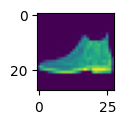

In [35]:
plt.figure(figsize=(1,1))
plt.imshow(test_images[0])
plt.show()

In [37]:
predicted_class=class_names[posicion]
print(f'Clase predicha: {predicted_class}')

Clase predicha: T-shirt/top
